In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')


In [2]:
df=pd.read_csv('insurance.csv')

In [3]:
df.shape

(1338, 7)

In [4]:
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [5]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [6]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [9]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [10]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [11]:
df['sex'].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

In [12]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

----------------------------------------------------------------------------------------

1️⃣ plt.figure(figsize=(8,6))
What it does:

Creates a new figure (graph window).

Sets the size of the plot.

figsize=(8,6) means:

Width = 8 inches

Height = 6 inches

👉 Why this matters:

If you don’t set size, plots may look too small or cramped

Especially important for heatmaps, where text and colors matter

----------------------------------------------------------------------------------------

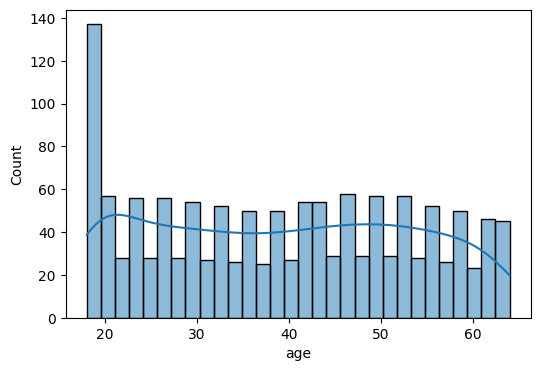

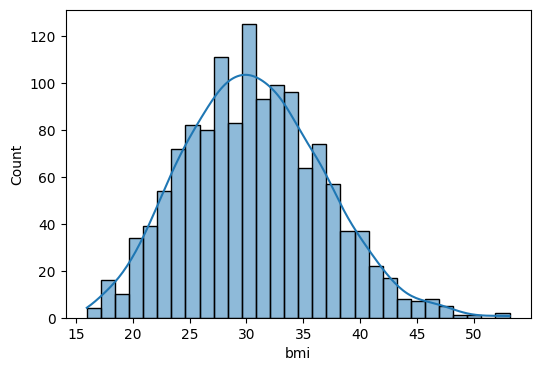

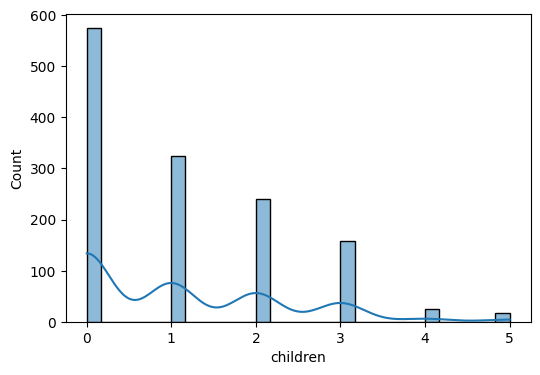

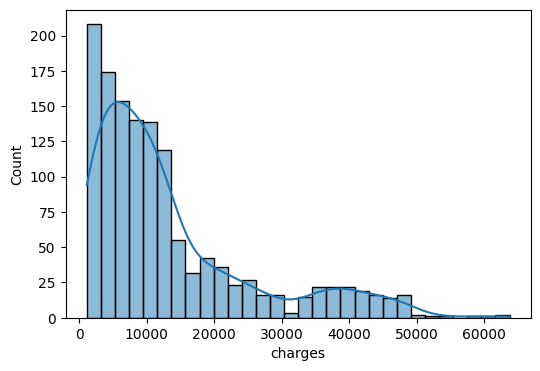

In [13]:
numeric_col=['age',  'bmi', 'children',  'charges']
for col in numeric_col:
    plt.figure(figsize=(6,4)) # plt.fugure is used to plot the data without overlapping and size is given 
    sns.histplot(df[col],kde=True,bins=30) # bins=20  mean to divide data into 20 bars  more bins more detail  

<Axes: xlabel='sex', ylabel='count'>

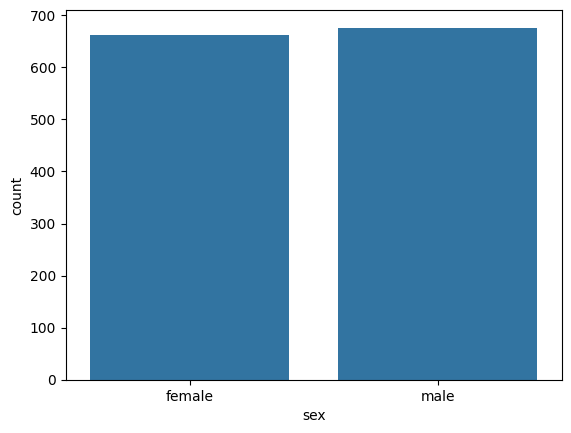

In [14]:
sns.countplot(x=df['sex']) # count plot is used to count the data it is used for categorical data nad discrete data 

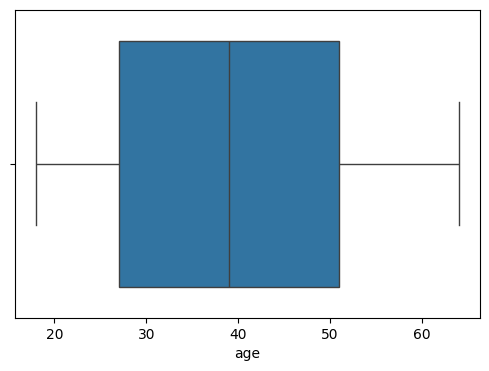

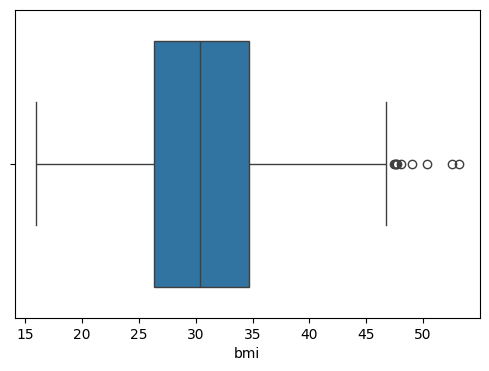

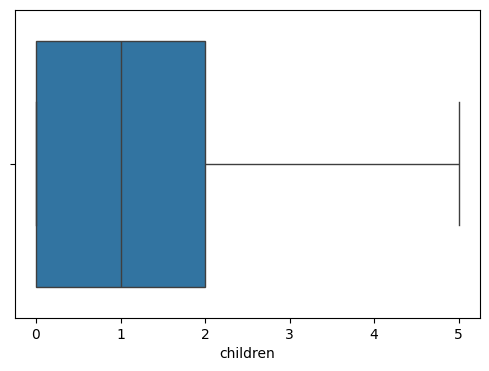

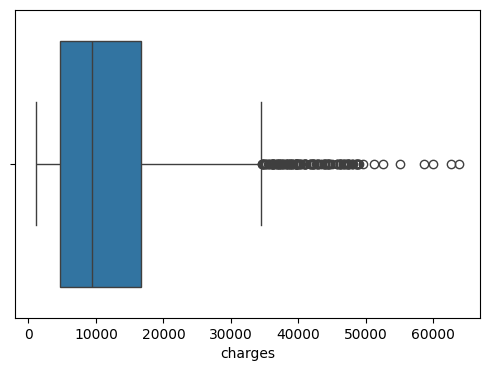

In [15]:
for col in numeric_col:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])

Boxplot: A graphical representation showing data distribution using quartiles and median.

Outlier: A data point that lies significantly outside the normal range of data.

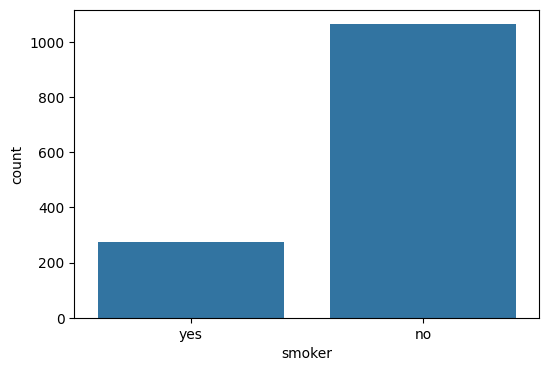

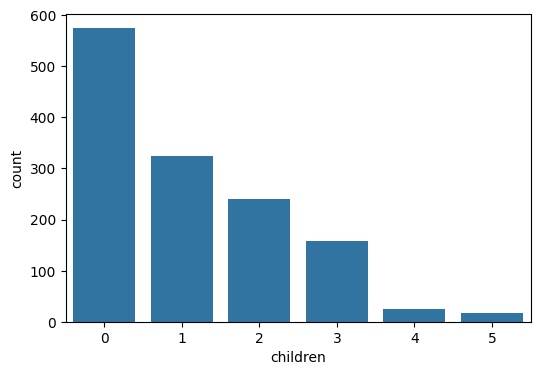

In [16]:
categorical_discrete_cols=['smoker','children']
for col in categorical_discrete_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col])

----------------------------------------------------------------------------------------


A heatmap is a data visualization tool that shows values using colors instead of numbers.

🔥 What it does (in simple terms):

It helps you quickly understand patterns, trends, and intensity in data.

High values → usually darker/hot colors (red, orange)
Low values → lighter/cool colors (blue, green)

CORELATION hmesha numerical value ka niklega 
2️⃣ df.corr(numeric_only=True)
What is df?

A Pandas DataFrame (your dataset)

What does .corr() do?

Computes the correlation matrix

Shows how strongly one numeric column is related to another

Correlation values:

+1 → perfect positive correlation

0 → no correlation

-1 → perfect negative correlation

📌 Example:



✅ Important because:

Correlation is only defined for numbers

Prevents errors if your dataset has categorical columns


annot=True is used to display the actual correaltion values inside each box

----------------------------------------------------------------------------------------

<Axes: >

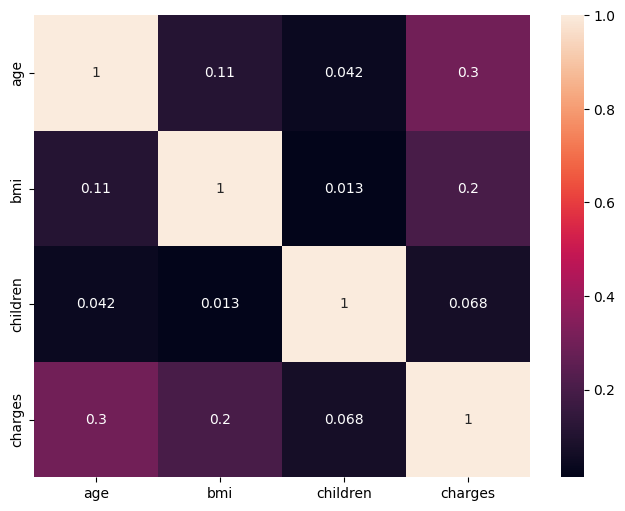

In [17]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True) # heatmap is used to find the correlation between the data and annot is used to show the value in the heatmap


----------------------------------------------------------------------------------------

What is sns?
-------

seaborn library

Used for beautiful and informative visualizations

What is a heatmap?

A color-based table

Each cell’s color shows the strength of correlation

👉 Darker / stronger color = stronger relationship

4️⃣ annot=True
What it does:

Writes the actual correlation value inside each cell

Without annot=True ❌:

You only see colors

With annot=True ✅:

You see values like:

----------------------------------------------------------------------------------------

In [18]:
df_cleaned=df.copy()
df_cleaned.shape

(1338, 7)

In [19]:
df_cleaned.drop_duplicates(inplace=True)  #inplace=true means change in orignal data frame 
df_cleaned.shape

(1337, 7)

In [20]:
df_cleaned["sex"].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [21]:
df_cleaned.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [22]:
df_cleaned['sex']=df_cleaned['sex'].map({"male":0,"female":1,})

In [23]:
df_cleaned.dtypes

age           int64
sex           int64
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [24]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [25]:
df_cleaned["smoker"]=df_cleaned["smoker"].map({"yes":1,"no":0})


In [26]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [27]:
df_cleaned["region"].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

----------------------------------------------------------------------------------------

pd.get_dummies(...)
---------------------------------

Converts categorical data into numerical form

Uses one-hot encoding

Models understand numbers, not text → this step is mandatory

🔹 drop_first=True kya karta hai?

drop_first=True one-hot encoding me ek dummy column hata deta hai.

👉 Simple words me:

Ek category ko reference bana ke uska column drop kar deta hai

----------------------------------------------------------------------------------------

In [28]:
df_cleaned=pd.get_dummies(df_cleaned,columns=["region"],drop_first=True)

In [29]:
df_cleaned.astype(int)

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0
1334,18,1,31,0,0,2205,0,0,0
1335,18,1,36,0,0,1629,0,1,0
1336,21,1,25,0,0,2007,0,0,1


----------------------------------
bmi_category → naya column banaya

pd.cut → numbers ko ranges me divide karta hai

df_cleaned["bmi"] → BMI values (numbers)

bins → BMI ki limits:

0–18.5 → underweight

18.5–24.9 → normal

24.9–29.9 → overweight

29.9+ → obese

float('inf') → 29.9 se upar kuch bhi

labels → har range ka naam

----------------------------------------------------------------------------------------

In [30]:
df_cleaned["bmi_category"]=pd.cut(
    df_cleaned["bmi"],
    bins=[0,18.5,24.9,29.9,float('inf')],
    labels=['underwight','normal','overweight','obese'])


In [31]:
df_cleaned

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27.900,0,1,16884.92400,False,False,True,overweight
1,18,0,33.770,1,0,1725.55230,False,True,False,obese
2,28,0,33.000,3,0,4449.46200,False,True,False,obese
3,33,0,22.705,0,0,21984.47061,True,False,False,normal
4,32,0,28.880,0,0,3866.85520,True,False,False,overweight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,True,False,False,obese
1334,18,1,31.920,0,0,2205.98080,False,False,False,obese
1335,18,1,36.850,0,0,1629.83350,False,True,False,obese
1336,21,1,25.800,0,0,2007.94500,False,False,True,overweight


----------------------------------------------------------------------------------------

FEATURE ENGINEERING AND FEATURE SCALING 
----------------------------------------------------------------------------------------

🔹 FEATURE ENGINEERING
-----------------------
Kya hota hai?

Raw data ko useful features me badalna taaki model achha kaam kare

Kya-kya aata hai isme?

Missing values handle karna

Categorical data ko numbers me badalna (get_dummies)

New features banana (bmi_category)

Unwanted columns remove karna

Outliers handle karna


FEATURE SCALING :
------------------
Feature scaling is the process of normalizing numerical features to a common scale.

----------------------------------------------------------------------------------------

In [32]:
from sklearn.preprocessing import StandardScaler
cols=['age','bmi','children']
scaler=StandardScaler()
df_cleaned[cols]=StandardScaler().fit_transform(df_cleaned[cols])

In [33]:
df_cleaned

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,-1.440418,1,-0.453160,-0.909234,1,16884.92400,False,False,True,overweight
1,-1.511647,0,0.509422,-0.079442,0,1725.55230,False,True,False,obese
2,-0.799350,0,0.383155,1.580143,0,4449.46200,False,True,False,obese
3,-0.443201,0,-1.305052,-0.909234,0,21984.47061,True,False,False,normal
4,-0.514431,0,-0.292456,-0.909234,0,3866.85520,True,False,False,overweight
...,...,...,...,...,...,...,...,...,...,...
1333,0.767704,0,0.050269,1.580143,0,10600.54830,True,False,False,obese
1334,-1.511647,1,0.206053,-0.909234,0,2205.98080,False,False,False,obese
1335,-1.511647,1,1.014490,-0.909234,0,1629.83350,False,True,False,obese
1336,-1.297958,1,-0.797524,-0.909234,0,2007.94500,False,False,True,overweight
